C:\Users\pmlbl\AppData\Local\Temp\ipykernel_14084\3162688109.py:42: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_total = pd.concat([df_total,df])
C:\Users\pmlbl\AppData\Local\Temp\ipykernel_14084\3162688109.py:57: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_total = pd.concat([df_total,df])


Text(0.5, 1.0, '100uA Zero Temp-Co Constant Diode Current Setpoint')

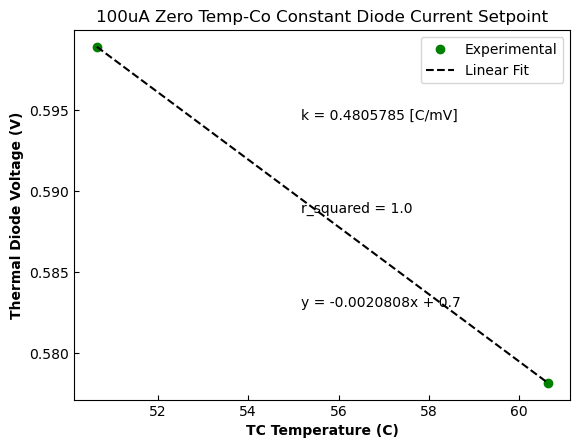

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import os 
import glob
import numpy as np

#set folder directory
#path = 'C:\\Lab_Data\\Data\\20250717\\D000'
path = 'C:\\Lab_Data\\Data\\20250722\\D002\\Iset_5.00e-05'

#iterate through all files in folder
def get_csvs(path):
    csvs = glob.glob(os.path.join(path, "*.csv"))
    return csvs

#extract Tset from each file
def get_setpoint(path,key):
    split_str = path.split('_')
    try:
        index = split_str.index(key)
    except ValueError:
        print(split_str)
        print(f"'{key}' is not found in the list.")
    setpoint = split_str[index+1]
    return setpoint

#average the data points for each Tset file
def get_value(f):
    df = pd.read_csv(f,names=['time','value'])
    avg_value = df.value.mean()
    return avg_value

def get_df_temp(path):
    df_total = pd.DataFrame(columns=['Temp_C','Temp_Setpoint'])
    for f in get_csvs(path):
        Tset = get_setpoint(f,key = 'TsetC')

        if 'Temp' in f:
            avg_temp = get_value(f)
            df = pd.DataFrame(columns=['Temp_C','Temp_Setpoint'])
            df.loc[0] = [avg_temp, Tset]
            df_total = pd.concat([df_total,df])
        else:
            pass
    return df_total


def get_df_volt(path):
    df_total = pd.DataFrame(columns=['Voltage_V','Temp_Setpoint'])
    for f in get_csvs(path):
        Tset = get_setpoint(f,key = 'TsetC')

        if 'Volt' in f:
            avg_volt = get_value(f)
            df = pd.DataFrame(columns=['Voltage_V','Temp_Setpoint'])
            df.loc[0] = [avg_volt, Tset]
            df_total = pd.concat([df_total,df])
        else:
            pass
    return df_total


#place all data in a single df
df_temp = get_df_temp(path)
df_volt = get_df_volt(path)

df_total = pd.concat([df_temp,df_volt])
a = df_total.groupby('Temp_Setpoint',as_index=False).agg(lambda x: x.tolist())

df_new = pd.DataFrame(columns=['Temp_C','Voltage_V','Temp_Setpoint'])

for x in range(len(a)):
    df_new.loc[x] = [a.Temp_C[x][0], a.Voltage_V[x][1],a.Temp_Setpoint[x]]

# #include linear regression fit, include equation of line on plot
x = df_new.Temp_C
y = df_new.Voltage_V
coef = np.polyfit(x,y,1)
poly1d_fn = np.poly1d(coef)

#r2 value
from sklearn.metrics import r2_score
r2 = r2_score(y, poly1d_fn(x))
# poly1d_fn is now a function which takes in x and returns an estimate for y

fig, ax = plt.subplots()

ax.plot(x,y, 'go', x, poly1d_fn(x), '--k') #'--k'=black dashed line
ax.tick_params(direction='in')
ax.set_xlabel('TC Temperature (C)', fontweight='bold')
ax.set_ylabel('Thermal Diode Voltage (V)', fontweight='bold')
ax.legend(['Experimental', 'Linear Fit'])
ax.text(ax.get_xlim()[0]*1.1,ax.get_ylim()[0]*1.01,'y = {}x + {}'.format(round(coef[0],7),round(coef[1],2))) #need to fix the text placement to be dependent on the axis location not with respective to data
ax.text(ax.get_xlim()[0]*1.1,ax.get_ylim()[0]*1.02, 'r_squared = {}'.format(round(r2,7)))
ax.text(ax.get_xlim()[0]*1.1,ax.get_ylim()[0]*1.03, 'k = {} [C/mV]'.format(abs(round((1/(1000*coef[0])),7))))
# ax.set_title('100uA Constant Diode Current Setpoint')
ax.set_title('100uA Zero Temp-Co Constant Diode Current Setpoint')